# Calculate Greenspace Index for Philadelhpia
NDVI + Park Proximity + Tree Canopy Coverage

### 1. Import nessecary modules

In [1]:
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
from rasterstats import zonal_stats
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# After downloading the NDVI raster from the previous notebook, set the file path here
ndvi_path = "../../data/philly_ndvi_2024_summer_fixed.tif"

# Load Philadelphia boundary file
phillygdf = gpd.read_file("../../data/City_Limits.geojson")

In [3]:
#Change CRS to match raster
phillygdf = phillygdf.to_crs("EPSG:2272")

In [4]:
# Verify the download
with rio.open(ndvi_path) as src:
    # clip to Philly boundary
    out_image, out_transform = mask(
        src,
        phillygdf.geometry,
        crop=True,
        nodata = np.nan
    )
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": np.nan
    })
    with rio.open("../../data/philly_ndvi_2024_summer_fixed_clipped.tif", "w", **out_meta) as dest:
        dest.write(out_image)



## 2. Census Tract Level Analysis

In [5]:
# Load Philly census tracts ACS 2022 
import pygris 
tracts = gpd.read_file("../../data/philly_neighborhoods.geojson")
# Change CRS to match raster
tracts = tracts.to_crs("EPSG:2272")

In [6]:
# Calculate zonal statistics for each census tract 
ndvi_stats = zonal_stats(
    tracts.geometry,
    "../../data/philly_ndvi_2024_summer_fixed_clipped.tif",
    stats=['mean', 'median', 'std', 'count'],
    nodata = np.nan
)

In [7]:
# Add stats to tracts GeoDataFrame
tracts['ndvi_mean'] = [stat['mean'] for stat in ndvi_stats]
tracts['ndvi_median'] = [stat['median'] for stat in ndvi_stats]
tracts['ndvi_std'] = [stat['std'] for stat in ndvi_stats]
tracts['ndvi_count'] = [stat['count'] for stat in ndvi_stats]

In [8]:
 # Summary statistics
print(f"\nNDVI Statistics Summary by Census Tract:")
print(tracts['ndvi_mean'].describe())
print(f"\nTracts with valid data: {(~tracts['ndvi_mean'].isna()).sum()}")
print(f"Tracts with NaN (water/no data): {tracts['ndvi_mean'].isna().sum()}")


NDVI Statistics Summary by Census Tract:
count    159.000000
mean       0.175613
std        0.074883
min        0.049723
25%        0.122809
50%        0.160066
75%        0.226397
max        0.408995
Name: ndvi_mean, dtype: float64

Tracts with valid data: 159
Tracts with NaN (water/no data): 0


### 2.1 Normalize NDVI values for easier interpretation scale (0-1)

In [9]:
ndvi_min = tracts['ndvi_mean'].min()
ndvi_max = tracts['ndvi_mean'].max()

tracts['ndvi_score'] = (tracts['ndvi_mean'] - ndvi_min) / (ndvi_max - ndvi_min)


In [10]:
# Save intermediate results
tracts.to_file('../../data/tracts_with_ndvi.geojson', driver='GeoJSON')

print(f"NDVI scores normalized to 0-1 scale")
print(f"Mean score: {tracts['ndvi_score'].mean():.3f}")


NDVI scores normalized to 0-1 scale
Mean score: 0.350


### 2.2 Let's visualize the NDVI scores across census tracts

In [11]:
import hvplot.pandas


tracts_plot = tracts.copy() # Create a copy for plotting
tracts_plot = tracts_plot.to_crs('EPSG:4326')  # Convert to lat/lon for hvplot

In [12]:
# Interactive choropleth
ndvi_map = tracts_plot.hvplot(
    c='ndvi_score',
    cmap='YlGn',
    hover_cols=['GEOID', 'ndvi_mean', 'ndvi_score'],
    tiles='CartoLight',
    alpha=0.7,
    frame_width=600,
    frame_height=500,
    title='NDVI Score by Census Tract - Philadelphia',
    clabel='NDVI Score'
)

ndvi_map

:Overlay
   .Tiles.I    :Tiles   [x,y]
   .Polygons.I :Polygons   [x,y]   (ndvi_score,ndvi_mean)

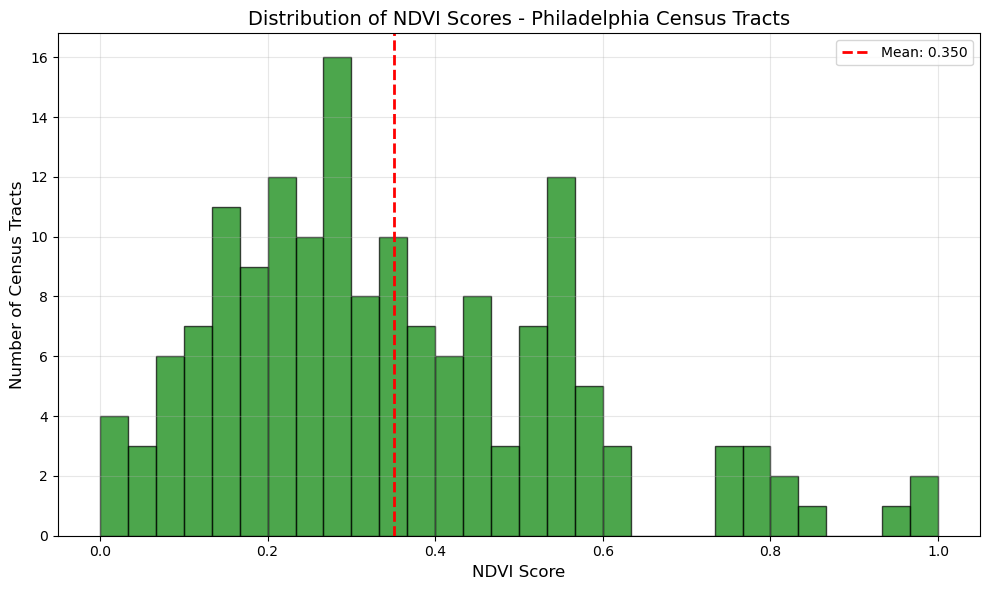

In [13]:
## Histogram
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(tracts['ndvi_score'].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution of NDVI Scores by Census Tract - Philadelphia')

# Add mean line
mean_ndvi = tracts['ndvi_score'].mean()
ax.axvline(mean_ndvi, color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {mean_ndvi:.3f}')
ax.set_xlabel('NDVI Score', fontsize=12)
ax.set_ylabel('Number of Census Tracts', fontsize=12)
ax.set_title('Distribution of NDVI Scores - Philadelphia Census Tracts', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/ndvi_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# --- NDVI CATEGORIES (0–1 normalized) ---
import pandas as pd
bins = [0.0, 0.1, 0.2, 0.35, 0.5, 1.0]  # Adjusted for your NDVI distribution
labels = ["Very Low", "Low", "Medium", "High", "Very High"]

tracts["ndvi_category"] = pd.cut(
    tracts["ndvi_score"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True
)

print(tracts["ndvi_category"].value_counts())


Medium       53
Very High    39
Low          27
High         27
Very Low     13
Name: ndvi_category, dtype: int64


In [15]:
print(tracts.shape)                 # should show number of rows
print(tracts.columns)               # make sure 'ndvi_category' exists
print(tracts['ndvi_category'].value_counts(dropna=False))


(159, 12)
Index(['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry',
       'ndvi_mean', 'ndvi_median', 'ndvi_std', 'ndvi_count', 'ndvi_score',
       'ndvi_category'],
      dtype='object')
Medium       53
Very High    39
Low          27
High         27
Very Low     13
Name: ndvi_category, dtype: int64


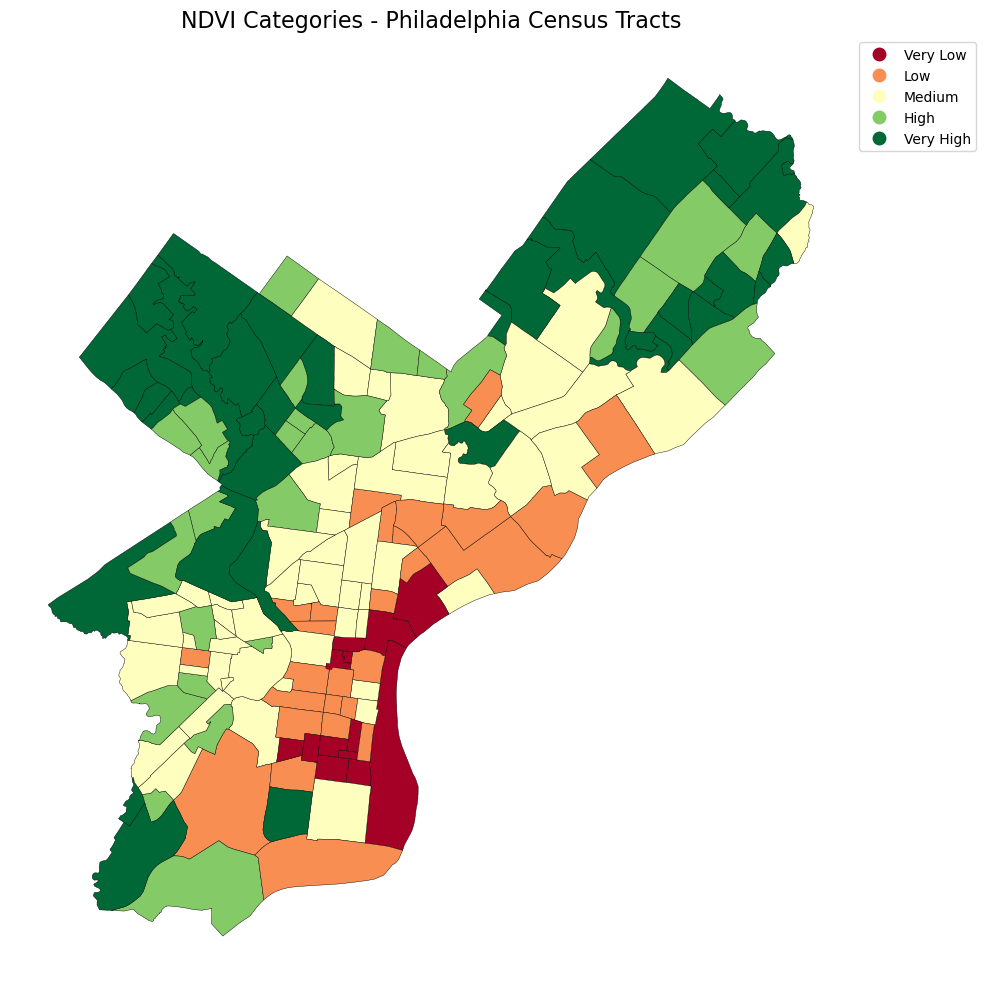

In [16]:
# Diagnostic Map
import pandas as pd
# Classify tracts into categories
def classify_ndvi(score):
    if score < 0.05:
        return 'Very Low (<0.2)'
    elif score < 0.2:
        return 'Low (0.2-0.4)'
    elif score < 0.3:
        return 'Medium (0.4-0.6)'
    elif score < 0.4:
        return 'High (0.6-0.8)'
    else:
        return 'Very High (>0.8)'

tracts['ndvi_category'] = tracts['ndvi_score'].apply(classify_ndvi)

##TO Order categories

# Example: NDVI categories
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

tracts['ndvi_category'] = pd.cut(
    tracts['ndvi_score'],  # your normalized NDVI 0-1
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Make sure the category is ordered
tracts['ndvi_category'] = tracts['ndvi_category'].cat.reorder_categories(labels, ordered=True)

# Plot categories
fig, ax = plt.subplots(figsize=(10, 10))
tracts.plot(
    column='ndvi_category',
    categorical=True,
    legend=True,
    cmap='RdYlGn',
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)
ax.set_title('NDVI Categories - Philadelphia Census Tracts', fontsize=16)
ax.axis('off')

plt.tight_layout()
plt.savefig('../../outputs/ndvi_categories.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
tracts[tracts['NAME'].str.contains('PASSYUNK', case=False, na=False)]


,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,ndvi_mean,ndvi_median,ndvi_std,ndvi_count,ndvi_score,ndvi_category
107,PASSYUNK_SQUARE,Passyunk Square,Passyunk Square,11751.503720,8.709396e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269243...",0.086059,0.074059,0.049929,899,0.101137,Low
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",0.073984,0.064798,0.031158,669,0.067529,Very Low
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",0.066270,0.061058,0.023454,671,0.046055,Very Low


### 3. Load park data & calculate distance to neaerest park for each census tract centroid

In [18]:
# Use OSMnx to get park locations in Philadelphia
phillygdf_84 = phillygdf.to_crs("EPSG:4326")  # OSMnx requires lat/lon CRS

parks = ox.features_from_polygon(
    phillygdf_84.unary_union,
    tags={'leisure': ['park', 'playground','dog_park', 'garden', 'pitch', 'recreation_ground']}
)



print(f"✅ Found {len(parks)} parks in Philadelphia")
print(f"   Total park area: {parks.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample parks:")
print(parks[['name', 'leisure']].head(10))


# Keep only essential columns for saving
parks_clean = parks[['geometry', 'name', 'leisure']].copy()

# Handle any NaN names
parks_clean['name'] = parks_clean['name'].fillna('Unnamed Park')

# Save cleaned version
parks_clean.to_file("../../data/philadelphia_parks_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(parks_clean)} parks to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull parks dataset has {len(parks.columns)} columns")
print(f"Available columns: {parks.columns.tolist()[:10]}...")  # Show first 10


✅ Found 3624 parks in Philadelphia


C:\Users\astau\AppData\Local\Temp\ipykernel_5644\21739700.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"   Total park area: {parks.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres


   Total park area: 0 acres

Sample parks:
                                                                     name  \
element_type osmid                                                          
node         357275889                                   Awbury Arboretum   
             357276509                         Belfield Recreation Center   
             357283944  Lonnie Young Recreation Center of East Germantown   
             357288965                          Shepard Recreation Center   
             357289574                                Harpers Hollow Park   
             357294803                                           Lee Park   
             357313728                     Starr Garden Recreation Center   
             357315908                                  Tacony Creek Park   
             357319279                        Waterview Recreation Center   
             357320161                                     Wharton Square   

                       leisure  

In [19]:
# ### Calculate distance to neaerest park for each census tract centroid
from scipy.spatial import cKDTree
from shapely.geometry import Point

In [20]:
# Get census tract centroids
tracts = tracts.to_crs(2272)
parks = parks.to_crs(2272)

tract_centroids = tracts.copy()
tract_centroids['geometry'] = tracts.geometry.centroid

# Get park boundaries (or centroids for small parks)
park_points = parks.geometry.representative_point()

# Build spatial index
park_coords = np.array([(p.x, p.y) for p in park_points])
tree = cKDTree(park_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = tree.query(tract_coords)

# Add distance (in feet for EPSG:2272)
tracts['park_distance_ft'] = distances

### 3.1 Convert distances to proximity scores (0-1 scale)

In [21]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = tracts['park_distance_ft'].min()
max_dist = tracts['park_distance_ft'].max()

tracts['park_proximity_score'] = 1 - (tracts['park_distance_ft'] - min_dist) / (max_dist - min_dist)



# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

### 4. Tree Canopy Raster Analysis

✅ Loaded 2,480 trees
   Columns: ['objectid', 'fcode', 'geometry']


<Axes: >

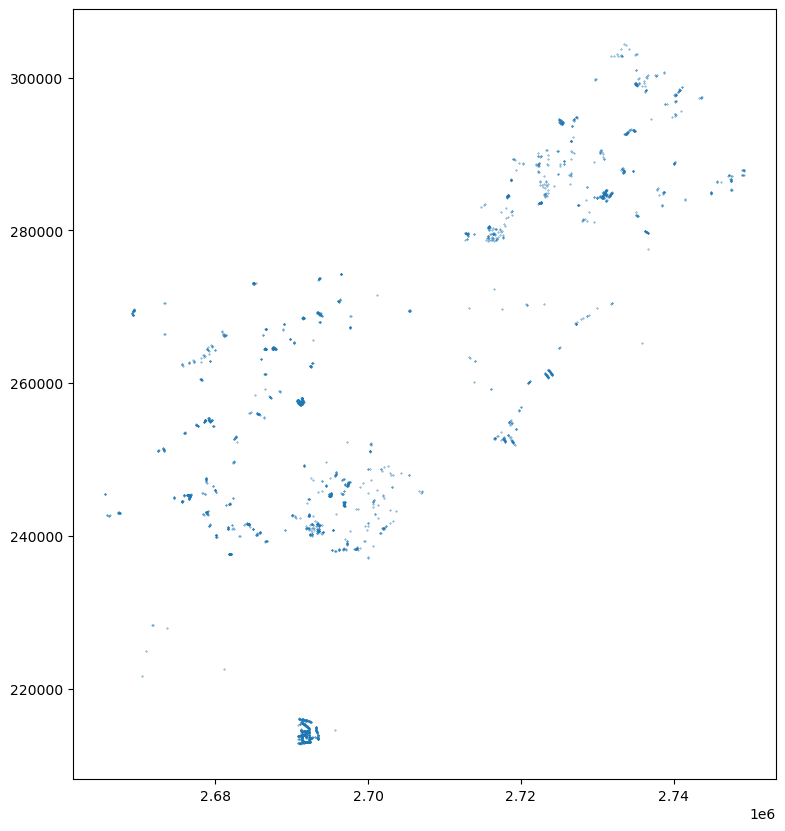

In [22]:
# Load tree point data
trees = gpd.read_file("../../data/ppr_tree_canopy_points_2015.geojson")

# Convert to EPSG:2272 to match tracts
trees = trees.to_crs('EPSG:2272')

print(f"✅ Loaded {len(trees):,} trees")
print(f"   Columns: {trees.columns.tolist()}")

# Quick check - visualize
trees.plot(markersize=0.1, figsize=(10, 10))

### 4.1 Count trees per census tract

In [23]:
tracts = tracts.to_crs(2272)
trees = trees.to_crs(2272)
# Spatial join - which tract is each tree in?
trees_with_tract = gpd.sjoin(trees, tracts[['NAME', 'geometry']], how='left', predicate='within')

# Count trees per tract
tree_counts = trees_with_tract.groupby('NAME').size().reset_index(name='tree_count')

# Merge back to tracts
tracts = tracts.merge(tree_counts, on='NAME', how='left')

# Fill NaN (tracts with no trees) with 0
tracts['tree_count'] = tracts['tree_count'].fillna(0)

print(f"Trees per neighborhood summary:")
print(tracts['tree_count'].describe())

Trees per neighborhood summary:
count    159.000000
mean      15.597484
std       43.444438
min        0.000000
25%        0.000000
50%        1.000000
75%       12.000000
max      438.000000
Name: tree_count, dtype: float64


### 4.2 Calculate & Normalize Tree Density Score (0-1 scale)

In [24]:
# Option A: Trees per square mile
tracts['area_sqmi'] = tracts.geometry.area / (5280**2)  # sq ft to sq miles
tracts['tree_density'] = tracts['tree_count'] / tracts['area_sqmi']

In [25]:
# Use min-max normalization
tree_min = tracts['tree_density'].min()
tree_max = tracts['tree_density'].max()

tracts['tree_score'] = (tracts['tree_density'] - tree_min) / (tree_max - tree_min)

# Or use quantile-based (if you have outliers)
# tracts['tree_score'] = tracts['tree_density'].rank(pct=True)

print(f"Tree score range: {tracts['tree_score'].min():.3f} to {tracts['tree_score'].max():.3f}")

Tree score range: 0.000 to 1.000


## Concot Greenspace Index by combining NDVI, Park Proximity, and Tree Density Scores equal weight

In [26]:
# Now combine all three components
tracts['greenspace_index'] = (
    tracts['ndvi_score'] * 0.33 +
    tracts['park_proximity_score'] * 0.33 +
    tracts['tree_score'] * 0.34
)

### Notes

In [27]:
# Save final greenspace index
tracts.to_file("../../data/philadelphia_greenspace_index.geojson", driver='GeoJSON')

print(f"✅ Greenspace index saved!")
print(f"   Tracts: {len(tracts)}")
print(f"   Mean score: {tracts['greenspace_index'].mean():.3f}")
print(f"   Range: {tracts['greenspace_index'].min():.3f} to {tracts['greenspace_index'].max():.3f}")

TypeError: Cannot interpret 'CategoricalDtype(categories=['Very Low', 'Low', 'Medium', 'High', 'Very High'], ordered=True)' as a data type

In [ ]:
print("="*60)
print("GREENSPACE INDEX COMPLETE")
print("="*60)
print(tracts['greenspace_index'].describe())

print(f"\nTop 5 Greenest Tracts:")
print(tracts.nlargest(5, 'greenspace_index')[['NAME', 'greenspace_index']])

print(f"\nLeast Green Tracts:")
print(tracts.nsmallest(5, 'greenspace_index')[['NAME', 'greenspace_index']])


GREENSPACE INDEX COMPLETE
count    159.000000
mean       0.409404
std        0.091719
min        0.064091
25%        0.350915
50%        0.399886
75%        0.470364
max        0.721960
Name: greenspace_index, dtype: float64

Top 5 Greenest Tracts:
                 NAME  greenspace_index
97      SPRING_GARDEN          0.721960
12   WISSAHICKON_PARK          0.640429
82           YORKTOWN          0.623151
158    BLUE_BELL_HILL          0.609459
8      PENNYPACK_PARK          0.608245

Least Green Tracts:
                  NAME  greenspace_index
111         INDUSTRIAL          0.064091
13          RIVERFRONT          0.176685
71       PORT_RICHMOND          0.221687
109  LOWER_MOYAMENSING          0.226868
112            AIRPORT          0.229157


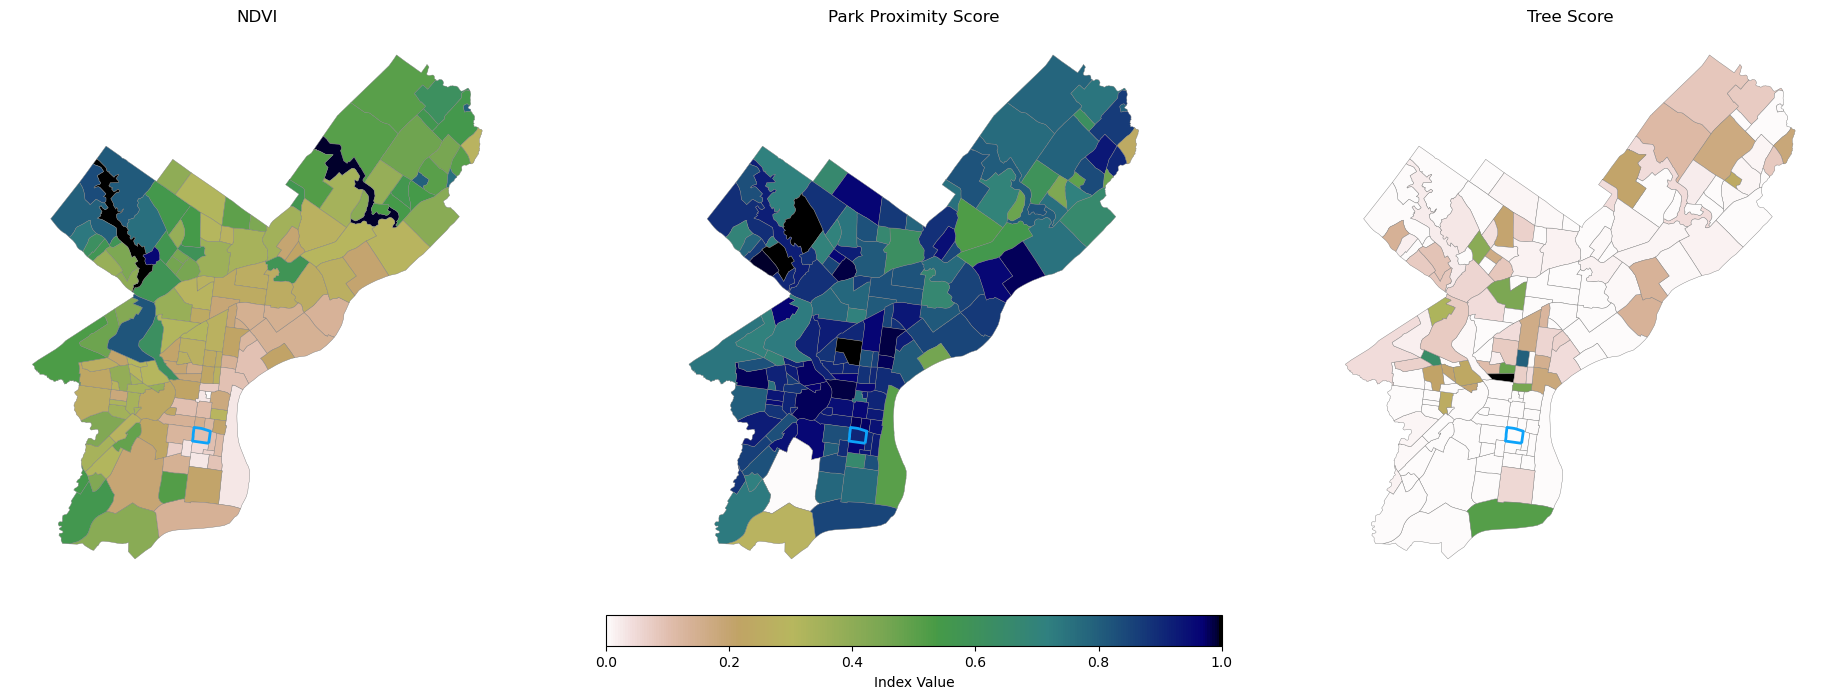

In [28]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    tracts["ndvi_score"].min(),
    tracts["park_proximity_score"].min(),
    tracts["tree_score"].min()
)

vmax = max(
    tracts["ndvi_score"].max(),
    tracts["park_proximity_score"].max(),
     tracts["tree_score"].max()
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "gist_earth_r"

# --- GET EAST PASSYUNK POLYGON ---
east_passyunk = tracts[tracts["NAME"] == "PASSYUNK_SQUARE"]

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
ax1, ax2, ax3 = axes


# -------------------------
# MAP 1 – Cartway Density
# -------------------------
tracts.plot(
    column="ndvi_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)

# Highlight East Passyunk
east_passyunk.boundary.plot(ax=ax1, color="#0CA3FA", linewidth=2)

ax1.set_title("NDVI")
ax1.axis("off")


# -------------------------
# MAP 2 – Bike Lane Index
# -------------------------
east_passyunk = tracts[tracts["NAME"] == "PASSYUNK_SQUARE"]

tracts.plot(
    column="park_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)

east_passyunk.boundary.plot(ax=ax2, color="#0CA3FA", linewidth=2)

ax2.set_title("Park Proximity Score")
ax2.axis("off")


# -------------------------
# MAP 3 – Sidewalk Index
# -------------------------
east_passyunk = tracts[tracts["NAME"] == "PASSYUNK_SQUARE"]

tracts.plot(
    column="tree_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax3
)

east_passyunk.boundary.plot(ax=ax3, color="#0CA3FA", linewidth=2)

ax3.set_title("Tree Score")
ax3.axis("off")


# -------------------------
# SHARED COLORBAR
# -------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Index Value")

plt.show()


In [ ]:
import geopandas as gpd

hoodgdf = gpd.read_file("../mobility/hoodgdf.gpkg")


In [ ]:
hoodgdf.columns.tolist()
tracts.columns.tolist()

['NAME',
 'LISTNAME',
 'MAPNAME',
 'Shape_Leng',
 'Shape_Area',
 'geometry',
 'ndvi_mean',
 'ndvi_median',
 'ndvi_std',
 'ndvi_count',
 'ndvi_score',
 'ndvi_category',
 'park_distance_ft',
 'park_proximity_score',
 'tree_count',
 'area_sqmi',
 'tree_density',
 'tree_score',
 'greenspace_index']

In [ ]:
# Prepare tracts for merging (keep original geometry)
tracts_for_merge = tracts.copy()

# --- Merge NDVI ---
hoodgdf = hoodgdf.merge(
    tracts_for_merge[["NAME", "ndvi_score"]],
    left_on="Name",
    right_on="NAME",
    how="left"
).drop(columns="NAME")

# --- Merge Park Proximity ---
hoodgdf = hoodgdf.merge(
    tracts_for_merge[["NAME", "park_proximity_score"]],
    left_on="Name",
    right_on="NAME",
    how="left"
).drop(columns="NAME")

# --- Merge Tree Score ---
hoodgdf = hoodgdf.merge(
    tracts_for_merge[["NAME", "tree_score"]],
    left_on="Name",
    right_on="NAME",
    how="left"
).drop(columns="NAME")


In [ ]:
hoodgdf

,Name,sidewalk_index,bike_index,cartway_density_index,geometry,ndvi_score,park_proximity_score,tree_score
0,LAWNDALE,0.981667,0.201329,0.633628,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...",0.353511,0.890186,0.000000
1,ASTON_WOODBRIDGE,0.946746,0.201768,0.682118,"POLYGON ((-75.00860 40.05369, -75.00861 40.053...",0.561259,0.436210,0.000000
2,CARROLL_PARK,0.964426,0.190563,0.735923,"POLYGON ((-75.22673 39.97720, -75.22022 39.974...",0.262774,0.826799,0.064857
3,CHESTNUT_HILL,0.950545,0.022636,0.439744,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...",0.805991,0.714609,0.000000
4,BURNHOLME,0.923102,0.145879,0.864792,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
153,DICKINSON_NARROWS,0.918205,0.096523,0.814234,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...",0.099397,0.909483,0.000000
154,GARDEN_COURT,1.012222,0.365182,0.926294,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...",0.328033,0.951685,0.000000
155,WISSAHICKON_HILLS,0.997497,0.436108,0.889194,"POLYGON ((-75.22010 40.03757, -75.22064 40.037...",0.584121,0.723416,0.000000
156,DEARNLEY_PARK,0.814339,0.206014,0.811131,"POLYGON ((-75.25136 40.04355, -75.25010 40.044...",0.734792,0.694044,0.139241


In [ ]:
hoodgdf.to_file("hoodgdf.gpkg", layer="hood", driver="GPKG")


In [ ]:
import pandas as pd
from scipy.stats import percentileofscore
import hvplot.pandas
import numpy as np

# ---------------------------------
# 1. Variables for Greenspace Index
# ---------------------------------
greenspace_vars = [
    "ndvi_score",
    "tree_score",
    "park_proximity_score",
    "greenspace_index"
]

# ---------------------------------
# 2. Compute citywide percentiles
# ---------------------------------
greenspace_df = tracts.copy()

for var in greenspace_vars:
    greenspace_df[var + "_pct"] = greenspace_df[var].apply(
        lambda x: percentileofscore(greenspace_df[var], x)
    )

# ---------------------------------
# 3. Identify EP neighborhoods
# ---------------------------------
ep_tracts = greenspace_df[
    greenspace_df["NAME"].str.contains("PASSYUNK", case=False, na=False)
]

# Rename neighborhoods for legend clarity
rename_map = {
    "EAST_PASSYUNK": "EP",
    "WEST_PASSYUNK": "WP",
    "PASSYUNK_SQUARE": "PS"
}

ep_tracts["NAME_SHORT"] = ep_tracts["NAME"].map(rename_map)

# Keep only the short name for legend grouping
cols = ["NAME_SHORT"] + [v + "_pct" for v in greenspace_vars]
ep_gs_pct = ep_tracts[cols].copy()

# ---------------------------------
# 4. Melt for interactive plotting
# ---------------------------------
ep_long = ep_gs_pct.melt(
    id_vars="NAME_SHORT",
    var_name="Variable",
    value_name="Percentile"
)

# Clean variable names
ep_long["Variable"] = (
    ep_long["Variable"]
    .str.replace("_pct", "")
    .str.replace("_", " ")
    .str.title()
)

# ---------------------------------
# 5. Interactive Plot
# ---------------------------------
interactive_plot = ep_long.hvplot.bar(
    x="Variable",
    y="Percentile",
    by="NAME_SHORT",           # legend uses short labels (EP, WP, PS)
    xlabel="Greenspace Variables",
    ylabel="Percentile (0–100)",
    title="Citywide Greenspace Percentiles — EP Neighborhoods",
    legend="top_right",
    height=450,
    width=800,
    hover_cols=["NAME_SHORT", "Percentile"]  # Hover stays informative
)

interactive_plot


c:\Users\astau\anaconda3\envs\geospatial\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


:Bars   [Variable,NAME_SHORT]   (Percentile,NAME_SHORT)

In [ ]:
tracts.columns.tolist()


['NAME',
 'LISTNAME',
 'MAPNAME',
 'Shape_Leng',
 'Shape_Area',
 'geometry',
 'ndvi_mean',
 'ndvi_median',
 'ndvi_std',
 'ndvi_count',
 'ndvi_score',
 'ndvi_category',
 'park_distance_ft',
 'park_proximity_score',
 'tree_count',
 'area_sqmi',
 'tree_density',
 'tree_score',
 'greenspace_index']